# PPO on CarRacing-v3 with Gymnasium and Stable-Baselines3

This project trains a reinforcement learning agent with Proximal Policy Optimization (PPO) on the `CarRacing-v3` environment from Gymnasium. The agent learns a driving policy directly from visual observations and is evaluated after training.

In [ ]:
%pip install "gymnasium[box2d]"
%pip install stable-baselines3
%pip install matplotlib
%pip install pandas
%pip install tqdm

## 1. Import Libraries

I first import the libraries needed for environment creation, training, monitoring, evaluation, and visualization.

In [2]:
import gymnasium as gym
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

## 2. Create and Inspect the Environment

I create the `CarRacing-v3` environment, inspect the initial observation, and verify that it follows the expected Gymnasium interface.

In [3]:
env = gym.make("CarRacing-v3")
obs, _ = env.reset()

print("Observation shape:", obs.shape)

check_env(env)

/Volumes/TestingTools/DevEnvs/anaconda3/envs/dataenv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Observation shape: (96, 96, 3)


/Volumes/TestingTools/DevEnvs/anaconda3/envs/dataenv/lib/python3.11/site-packages/stable_baselines3/common/env_checker.py:461: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


## 3. Visualize Observations

To better understand the state space, I visualize the initial frame and a few later observations after random actions. This shows how the environment changes over time and what the agent sees while interacting with the track.

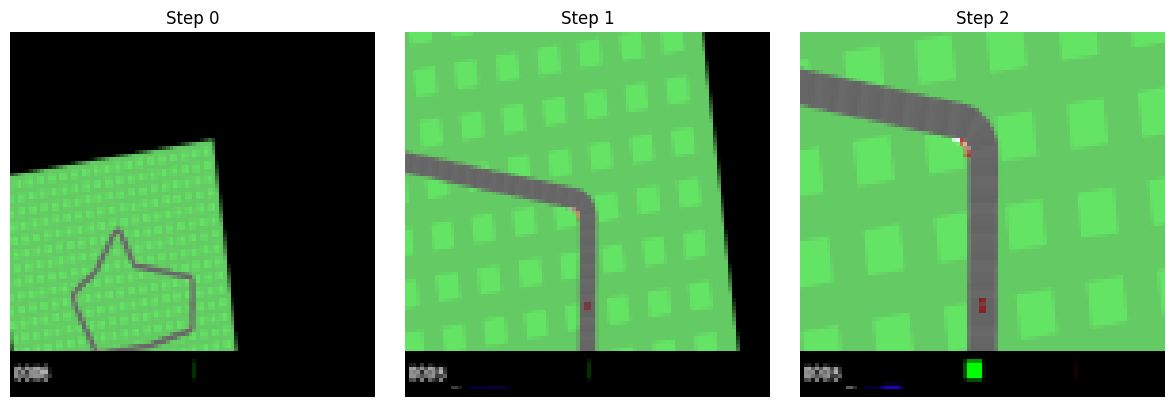

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

obs, _ = env.reset()
axes[0].imshow(obs)
axes[0].set_title("Step 0")
axes[0].axis("off")

for i in range(1, 3):
    for _ in range(8):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            obs, _ = env.reset()
    axes[i].imshow(obs)
    axes[i].set_title(f"Step {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 4. Create the PPO Agent

Next, I wrap the environment with `Monitor` to log episode rewards and lengths during training. Then I initialize a PPO agent with `CnnPolicy`, which is suitable for image-based observations.

In [5]:
env = gym.make("CarRacing-v3")
env = Monitor(env, "./logs")

model = PPO("CnnPolicy", env, verbose=1, device="cpu")

Using cpu device
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


## 5. Train the Agent

I train the PPO agent for 100,000 timesteps and save the trained model for later evaluation.

In [6]:
model.learn(total_timesteps=100000)
model.save("ppo_carracing_100k")

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -54.2    |
| time/              |          |
|    fps             | 83       |
|    iterations      | 1        |
|    time_elapsed    | 24       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -51.4       |
| time/                   |             |
|    fps                  | 61          |
|    iterations           | 2           |
|    time_elapsed         | 66          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008406576 |
|    clip_fraction        | 0.0865      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.27       |
|    explained_variance   | -0.0106     |
|    learning_rate        | 0.

The trained agent achieved a mean reward of approximately **122** over 50 evaluation episodes, with a standard deviation of about **115**.

This indicates that the agent has learned a partially effective driving policy, but performance is still unstable. While the agent can achieve positive rewards, the high variance suggests that it struggles to consistently follow the track across episodes.

## 6. Training Reward Curve

To track learning progress, I load the reward logs recorded by `Monitor` and plot episode rewards over time.

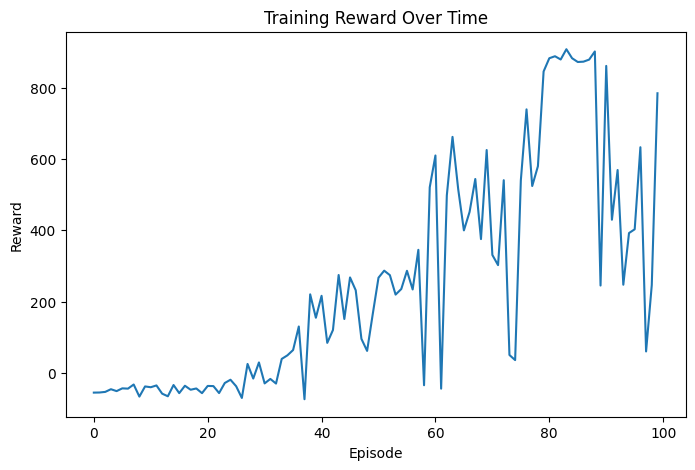

In [7]:
log_data = pd.read_csv("./logs.monitor.csv", skiprows=1)

plt.figure(figsize=(8, 5))
plt.plot(log_data["r"])
plt.title("Training Reward Over Time")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

The reward curve shows a gradual improvement from negative rewards in the early episodes to higher rewards later in training. However, the curve remains highly variable, indicating that learning is not yet stable.

This behavior is common in reinforcement learning, especially in environments with high-dimensional visual inputs like CarRacing-v3.

## 7. Evaluate the Agent

Finally, I evaluate the trained policy over 50 episodes and report the mean and standard deviation of total reward.

In [8]:
eval_env = gym.make("CarRacing-v3")

mean_reward, std_reward = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=50,
    deterministic=True
)

results = pd.DataFrame({
    "Timesteps": [100000],
    "Mean Reward": [mean_reward],
    "Std Reward": [std_reward]
})

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)

results

/Volumes/TestingTools/DevEnvs/anaconda3/envs/dataenv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Mean reward: 122.47043093338608
Std reward: 115.1176289331132


,Timesteps,Mean Reward,Std Reward
0,100000,122.470431,115.117629


The trained agent achieved a mean reward of approximately **122** over 50 evaluation episodes, with a standard deviation of about **115**.

This indicates that the agent has learned a partially effective driving policy, but performance is still unstable. While the agent can achieve positive rewards, the high variance suggests that it struggles to consistently follow the track across episodes.

## Reflection

This project demonstrates an end-to-end reinforcement learning workflow, including environment setup, visualization, PPO training, reward tracking, and evaluation.

The agent shows clear learning progress, improving from negative rewards to positive performance. However, the evaluation results reveal that the learned policy is still unstable, as indicated by the high variance in rewards across episodes.

This suggests that while PPO is capable of learning meaningful behavior in CarRacing-v3, additional training and tuning are required to achieve consistent performance.

Possible improvements include:
- increasing training timesteps
- tuning PPO hyperparameters
- applying observation preprocessing (e.g., frame stacking)
- comparing with alternative algorithms such as SAC